In [1]:
print("Hello world")

Hello world


In [26]:
import pandas as pd
import numpy as np
from pymongo import MongoClient
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
#connecting to MongoDB client
client = MongoClient(
    "mongodb://100.103.177.85:27017",
    directConnection=True,
    serverSelectionTimeoutMS=10000,
)

db = client["booktestdbgp_test"]
print("Connected ✅")

Connected ✅


In [3]:
# Live Casino settled transactions only
# betParts ke andar se game name extract karna padega

raw_transactions = list(db["bet_transactions"].find(
    {
        "gameType": "Live Casino",
        "status": "SETTLED",
        "betParts": {"$exists": True, "$ne": []}
    }
))

transactions_df = pd.DataFrame(raw_transactions)
print(f"Raw transactions loaded: {len(transactions_df)}")
print(transactions_df.columns.tolist())

Raw transactions loaded: 197
['_id', 'category', 'gameType', 'ticketId', 'channel', 'status', 'createdDate', 'stake', 'currency', 'potentialPayout', 'isFreeBet', 'stakeBonus', 'stakeReal', 'minOdds', 'maxOdds', 'minPayout', 'maxPayout', 'freeBetId', 'bonusType', 'resultedDate', 'betType', 'betParts', 'cashoutHistory', 'dynamicMultiCorrectSelections', 'shortBetId', 'loginId', 'fromAccountId', 'fromAccountAmount', 'toAccountId', 'toAccountAmount', 'bonusAccountInfo', 'aggregatorId', 'aggregatorActionId', 'createdAt', 'updatedAt', '__v', 'payout', 'result', 'oddsChangeType', 'remainingStake', 'isPartialCoBet', 'totalOdds', 'cashoutStatus', 'bonusWinnings', 'bonusPercentage', 'groupCount', 'combinationCount', 'maxWinAmount', 'maxWinPercentage', 'clientMaxPayout', 'stakeTaxAmount', 'winningTaxAmount', 'stakeTax', 'winningTax', 'stakeAfterTax', 'totalStake', 'isNftHoldingCreated', 'isNftTraded', 'subBetType', 'betEligibleForOneCutBonus', 'betEligibleForTwoCutBonus', 'partialCoBet', 'maxPayou

In [4]:
# extracting first element of betParts array
# game name, vendor, category wahan hai

def extract_bet_part(betParts):
    if betParts and len(betParts) > 0:
        part = betParts[0]
        return {
            "sportName":    part.get("sportName", None),
            "categoryName": part.get("categoryName", None),
            "vendor":       part.get("tournamentName", None),
        }
    return {"sportName": None, "categoryName": None, "vendor": None}

bet_parts_expanded = transactions_df["betParts"].apply(extract_bet_part)
bet_parts_df = pd.DataFrame(bet_parts_expanded.tolist())

transactions_df = pd.concat(
    [transactions_df.drop(columns=["betParts"]), bet_parts_df], 
    axis=1
)

print(transactions_df[["loginId", "stake", "result", 
                         "sportName", "vendor", "categoryName"]].sample(5))

        loginId  stake result        sportName    vendor categoryName
132  6888888888   8000   LOSE          Aviator    Spribe   Crash Game
62   6666622222    107   LOSE    Cricket Crash  OnlyPlay   Crash Game
107  6677777777   1000    WIN    Cricket Crash  OnlyPlay   Crash Game
67   6258974310    100    WIN  Football studio     EvoSW  Live Casino
52   6677777777    300   LOSE             None      None         None


In [5]:
# Rename fields to match recsys.ipynb schema
transactions_df = transactions_df.rename(columns={
    "loginId":      "userId",
    "stake":        "betAmount",
    "createdDate":  "timestamp",
    "sportName":    "gameName",
    "vendor":       "providerName",
})

# Session duration — createdDate se resultedDate tak
transactions_df["sessionDuration"] = (
    pd.to_datetime(transactions_df["resultedDate"]) - 
    pd.to_datetime(transactions_df["timestamp"])
).dt.total_seconds() / 60  # minutes mein

# Time features
transactions_df["timestamp"] = pd.to_datetime(transactions_df["timestamp"])
transactions_df["hourOfDay"]  = transactions_df["timestamp"].dt.hour
transactions_df["dayOfWeek"]  = transactions_df["timestamp"].dt.day_name()

# Sirf jo chahiye
transactions_df = transactions_df[[
    "userId", "gameName", "providerName", "categoryName",
    "betAmount", "result", "sessionDuration",
    "timestamp", "hourOfDay", "dayOfWeek"
]].copy()

# Nulls drop
transactions_df = transactions_df.dropna(subset=["userId", "gameName", "betAmount"])

print(f"Clean transactions: {len(transactions_df)}")
print(transactions_df.dtypes)
print(transactions_df.sample(3))

Clean transactions: 144
userId                     object
gameName                   object
providerName               object
categoryName               object
betAmount                   int64
result                     object
sessionDuration           float64
timestamp          datetime64[ns]
hourOfDay                   int32
dayOfWeek                  object
dtype: object
         userId       gameName providerName categoryName  betAmount result  \
89   3265459874  Cricket Crash     OnlyPlay   Crash Game        100   LOSE   
141  7878787878   Super Sic Bo        EvoSW  Live Casino        200   LOSE   
147  5555533333   Super Sic Bo        EvoSW  Live Casino        100   LOSE   

     sessionDuration               timestamp  hourOfDay dayOfWeek  
89          0.247583 2026-02-24 10:17:34.883         10   Tuesday  
141         0.116200 2026-03-02 06:32:41.742          6    Monday  
147         0.107867 2026-03-02 08:00:08.148          8    Monday  


In [6]:
#load games 

games_raw = list(db["gamedetails"].find(
    {"gameStatus": "ON"},
    {"gameId": 1, "gameName": 1, "minBet": 1, 
     "maxBet": 1, "category": 1, "gamevendor": 1}
))

games_df = pd.DataFrame(games_raw)

# Category name extract karo
games_df["gameType"] = games_df["category"].apply(
    lambda x: x[0]["name"] if x and len(x) > 0 else "Unknown"
)

games_df = games_df.rename(columns={"gameName": "gameName"})
games_df = games_df[["gameId", "gameName", "gameType", "minBet", "maxBet"]]

print(f"Games loaded: {len(games_df)}")
print(games_df.sample(5))

Games loaded: 76
     gameId               gameName     gameType  minBet  maxBet
46  2162240                   Goal       Spribe     100  100000
23  2887136        Lightning Storm  Live Casino     100  100000
55  2669529             Home Run X        Crash     100  100000
16  2419164  Dead or Alive: Saloon  Live Casino     100  100000
29  2412792   Football Studio Dice  Live Casino     100  100000


In [7]:
#load users

users_raw = list(db["players"].find(
    {"activeStatus": True},
    {"playerId": 1, "username": 1, "contactNo": 1, "activeStatus": 1}
))

users_df = pd.DataFrame(users_raw)

# userId consistent banana — transactions mein loginId = contactNo hai
users_df = users_df.rename(columns={"contactNo": "userId"})
users_df = users_df[["userId", "playerId", "activeStatus"]]

print(f"Users loaded: {len(users_df)}")
print(users_df.head(3))

Users loaded: 135
       userId  playerId  activeStatus
0  5555555555  10003490          True
1  5555577777  10003491          True
2  6677777777  10003492          True


In [8]:
print("=== DATA SUMMARY ===")
print(f"Transactions:   {len(transactions_df)}")
print(f"Unique users:   {transactions_df['userId'].nunique()}")
print(f"Unique games:   {transactions_df['gameName'].nunique()}")
print(f"Date range:     {transactions_df['timestamp'].min()} → {transactions_df['timestamp'].max()}")
print(f"\nGame distribution:")
print(transactions_df['gameName'].value_counts())
print(f"\nResult distribution:")
print(transactions_df['result'].value_counts())
print(f"\nNull check:")
print(transactions_df.isnull().sum())

=== DATA SUMMARY ===
Transactions:   144
Unique users:   18
Unique games:   12
Date range:     2026-02-19 09:19:13.543000 → 2026-03-03 12:27:35.929000

Game distribution:
gameName
Aviator                 35
Super Sic Bo            34
Cricket Crash           27
Quantum X               15
Dragon Tiger             9
Football studio          5
CosmoX                   5
998:baccarat             5
Football Studio Dice     5
Fan Tan                  2
Casino Hold'em           1
Bac Bo                   1
Name: count, dtype: int64

Result distribution:
result
LOSE    86
WIN     58
Name: count, dtype: int64

Null check:
userId             0
gameName           0
providerName       0
categoryName       0
betAmount          0
result             0
sessionDuration    0
timestamp          0
hourOfDay          0
dayOfWeek          0
dtype: int64


In [9]:
# 1. sessionDuration drop karo — not reliable
transactions_df = transactions_df.drop(columns=["sessionDuration"])

# 2. Messy game names clean karo
game_name_map = {
    "998:baccarat": "Baccarat",
    "Football studio": "Football Studio",
}
transactions_df["gameName"] = transactions_df["gameName"].replace(game_name_map)

# 3. gameId add karo from games_df for joining
transactions_df = transactions_df.merge(
    games_df[["gameName", "gameId", "minBet", "maxBet"]],
    on="gameName",
    how="left"
)

# 4. result → binary win flag
transactions_df["win"] = (transactions_df["result"] == "WIN").astype(int)

print(f"After cleaning: {len(transactions_df)}")
print(f"Games with gameId matched: {transactions_df['gameId'].notna().sum()}")
print(transactions_df[["userId", "gameName", "gameId", "betAmount", "win"]].sample(5))

After cleaning: 179
Games with gameId matched: 169
       userId      gameName   gameId  betAmount  win
0  7878787878  Super Sic Bo  1571026        400    0
1  6677777777  Super Sic Bo  1571026        400    0
2  6677777777  Super Sic Bo  1571026        500    0
3  6677777777  Super Sic Bo  1571026        500    0
4  6677777777  Super Sic Bo  1571026        400    0


In [10]:
print(transactions_df[["userId", "gameName", "gameId", "betAmount", "win"]].sample(5))

         userId      gameName   gameId  betAmount  win
50   6969696969     Quantum X  2452312        107    1
70   6888888888       Aviator  2162016       7000    0
1    6677777777  Super Sic Bo  1571026        400    0
5    6677777777  Super Sic Bo  1571026        400    0
125  5555533333  Dragon Tiger  1571005        100    1


In [11]:
print("=== FINAL DATA READINESS CHECK ===")

# Transactions per user
txn_per_user = transactions_df.groupby("userId").size()
print(f"\nTransactions per user:")
print(txn_per_user.describe().round(2))
print(f"\nUsers with only 1 transaction: {(txn_per_user == 1).sum()}")
print(f"Users with 5+ transactions:    {(txn_per_user >= 5).sum()}")

# Games coverage
print(f"\nGames in transactions: {transactions_df['gameName'].nunique()}")
print(f"Games in games_df:     {len(games_df)}")

# User coverage
matched_users = transactions_df['userId'].isin(users_df['userId']).sum()
print(f"\nTransactions matched to players collection: {matched_users}/{len(transactions_df)}")

=== FINAL DATA READINESS CHECK ===

Transactions per user:
count    18.00
mean      9.94
std      11.64
min       1.00
25%       2.00
50%       6.50
75%      12.75
max      42.00
dtype: float64

Users with only 1 transaction: 3
Users with 5+ transactions:    10

Games in transactions: 12
Games in games_df:     76

Transactions matched to players collection: 179/179


In [12]:
#user session log 

db = client["booktestdbgp_test"]
count = db["usersessionlog"].estimated_document_count()
sample5 = list(db["usersessionlog"].find(
    {"source": "livecasino", "status": "Closed"}
).limit(5))

for s in sample5:
    duration = (s["updated_at"] - s["created_at"]).total_seconds()
    print(f"user: {s['user_id']} | game: {s['game_id']} | duration: {duration}s")

print(f"\nTotal session logs: {count}")
print(f"Live casino closed: {db['usersessionlog'].count_documents({'source': 'livecasino', 'status': 'Closed'})}")

user: 4333333333 | game: 1476419 | duration: 5.436s
user: 4333333333 | game: 1476422 | duration: 4.181s
user: 6258974310 | game: 1570996 | duration: 550.396s
user: 7878787878 | game: 1571026 | duration: 6.227s
user: 5555533333 | game: 1571026 | duration: 51.302s

Total session logs: 81
Live casino closed: 47


Problem 1 — Volume
47 sessions, 179 transactions
Join karne ke baad sirf kuch hi 
matches milenge — aur bhi sparse ho jaayega

Problem 2 — Quality
5 second sessions = noise hai
Real gameplay vs accidental open 
differentiate karna padega
Threshold: < 30 seconds = drop karo

In [13]:
# Sabhi unique users ke sessions dekho
pipeline = [
    {"$match": {"source": "livecasino", "status": "Closed"}},
    {"$addFields": {
        "duration_seconds": {
            "$divide": [
                {"$subtract": ["$updated_at", "$created_at"]},
                1000
            ]
        }
    }},
    {"$group": {
        "_id": "$user_id",
        "total_sessions": {"$sum": 1},
        "avg_duration":   {"$avg": "$duration_seconds"},
        "max_duration":   {"$max": "$duration_seconds"},
        "min_duration":   {"$min": "$duration_seconds"},
    }},
    {"$sort": {"total_sessions": -1}}
]

print("=== Per User Session Stats ===")
for doc in db["usersessionlog"].aggregate(pipeline):
    print(f"user: {doc['_id']} | sessions: {doc['total_sessions']} | "
          f"avg: {doc['avg_duration']:.1f}s | "
          f"max: {doc['max_duration']:.1f}s | "
          f"min: {doc['min_duration']:.1f}s")

=== Per User Session Stats ===
user: 5555533333 | sessions: 23 | avg: 49.1s | max: 207.5s | min: 2.8s
user: 7878787878 | sessions: 7 | avg: 463.2s | max: 1721.6s | min: 2.0s
user: 4333333333 | sessions: 3 | avg: 6.7s | max: 10.5s | min: 4.2s
user: 7444444444 | sessions: 3 | avg: 48.2s | max: 72.6s | min: 16.0s
user: 6222222222 | sessions: 2 | avg: 30.6s | max: 48.6s | min: 12.7s
user: 7555555555 | sessions: 2 | avg: 54.2s | max: 77.0s | min: 31.4s
user: 6678480800 | sessions: 2 | avg: 6.2s | max: 7.3s | min: 5.1s
user: 9222222222 | sessions: 2 | avg: 63.8s | max: 68.1s | min: 59.6s
user: 6258974310 | sessions: 1 | avg: 550.4s | max: 550.4s | min: 550.4s
user: 5111111111 | sessions: 1 | avg: 51.6s | max: 51.6s | min: 51.6s
user: 4588888888 | sessions: 1 | avg: 311.7s | max: 311.7s | min: 311.7s


In [14]:
pipeline = [
    {"$match": {"source": "livecasino", "status": "Closed"}},
    {"$addFields": {
        "duration_seconds": {
            "$divide": [
                {"$subtract": ["$updated_at", "$created_at"]},
                1000
            ]
        }
    }},
    {"$group": {
        "_id": "$game_id",
        "total_sessions": {"$sum": 1},
        "avg_duration":   {"$avg": "$duration_seconds"},
        "max_duration":   {"$max": "$duration_seconds"},
        "min_duration":   {"$min": "$duration_seconds"},
    }},
    {"$sort": {"avg_duration": 1}}
]

# Game name join karo from gamedetails
results = list(db["usersessionlog"].aggregate(pipeline))

# gamedetails se name laao
game_lookup = {
    str(g["gameId"]): g["gameName"] 
    for g in db["gamedetails"].find({}, {"gameId": 1, "gameName": 1})
}

print(f"{'Game Name':<35} {'ID':<12} {'Sessions':<10} {'Avg(s)':<10} {'Max(s)':<10} {'Min(s)'}")
print("-" * 90)
for doc in results:
    game_id   = str(doc["_id"])
    game_name = game_lookup.get(game_id, "Unknown")
    print(f"{game_name:<35} {game_id:<12} {doc['total_sessions']:<10} "
          f"{doc['avg_duration']:<10.1f} {doc['max_duration']:<10.1f} {doc['min_duration']:.1f}")

Game Name                           ID           Sessions   Avg(s)     Max(s)     Min(s)
------------------------------------------------------------------------------------------
Bac Bo                              2156000      1          2.0        2.0        2.0
Ultimate Texas Holdem               1476419      1          5.4        5.4        5.4
Triple Card Poker                   1476422      4          15.2       48.6       2.8
Baccarat A (851)                    1476401      6          62.6       207.5      7.3
Dragon Tiger                        1571005      5          70.7       99.4       53.0
Fan Tan                             2058406      1          100.0      100.0      100.0
Super Sic Bo                        1571026      27         148.2      1721.6     2.8
Football Studio Dice                2412792      1          311.7      311.7      311.7
Tolkacova American Roulette         1570996      1          550.4      550.4      550.4


## CELL 2 — Basic EDA
> Adapted from recsys.ipynb for real data schema
> - Uses `categoryName` as game type, `providerName` as vendor
> - No archetype (was simulated only)
> - sessionDuration dropped (unreliable in real data)

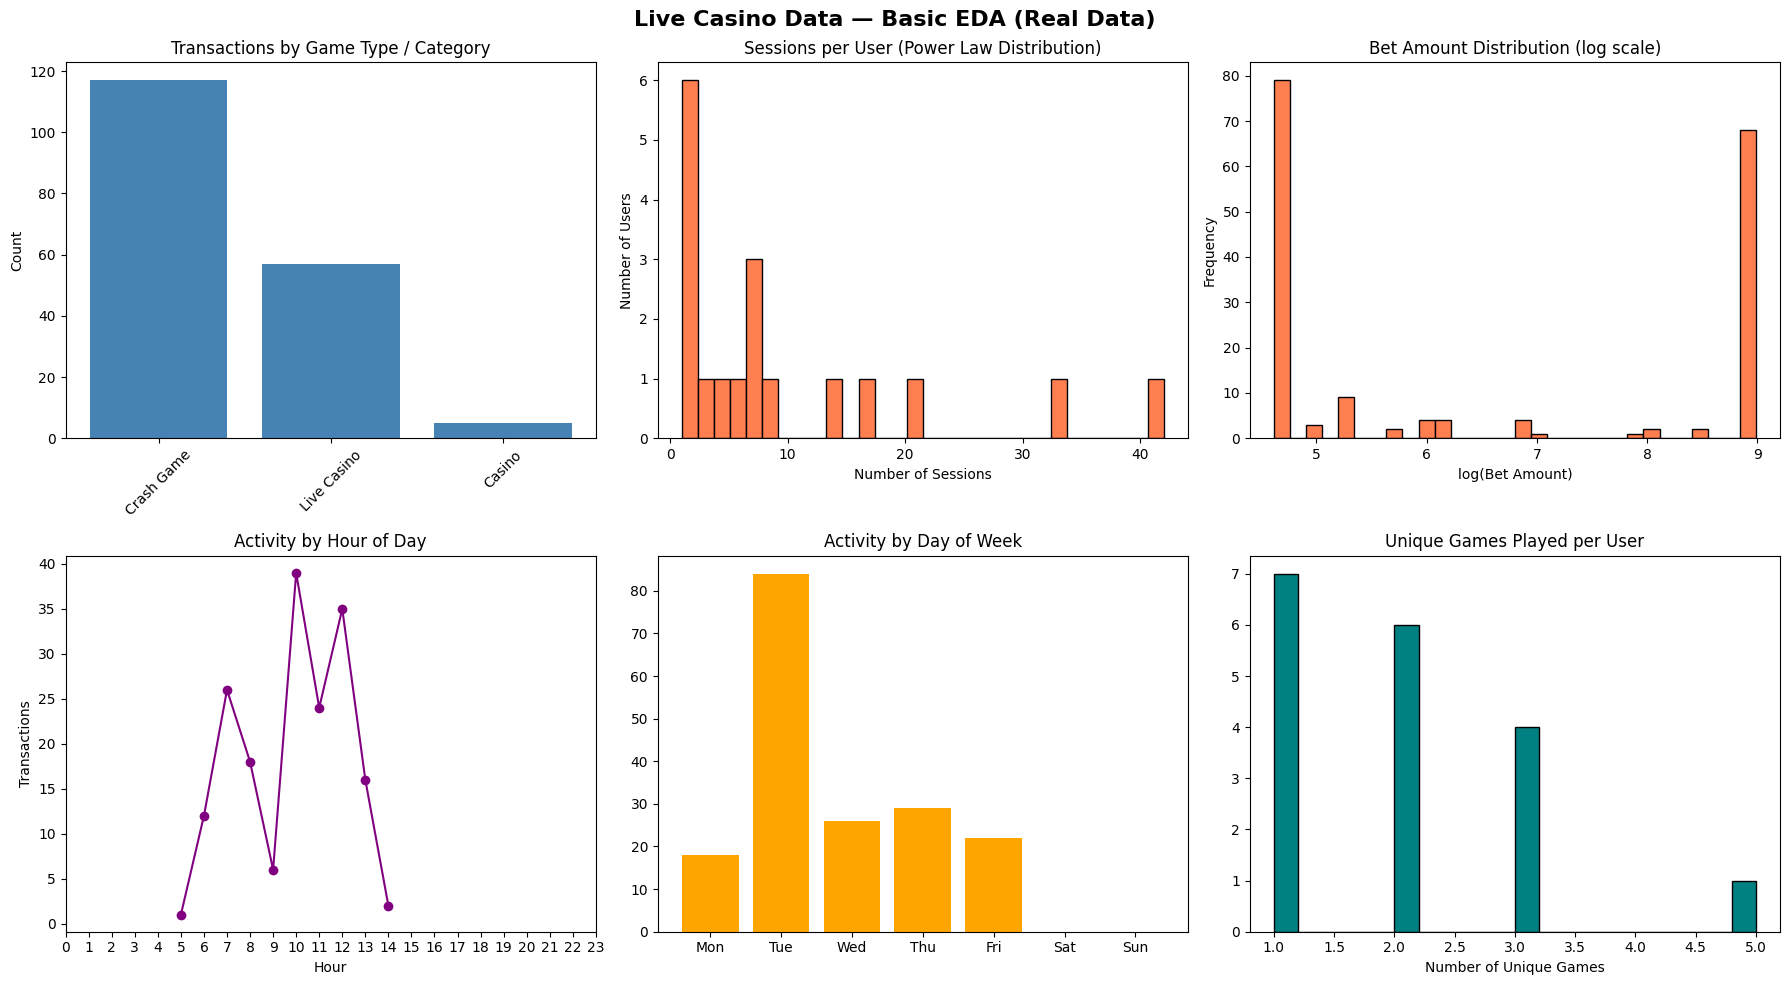


📊 Key Stats:
  Total transactions:         179
  Active users (≥1 tx):       18
  Median sessions/user:       6
  Avg unique games/user:      2.0
  Interaction density:        16.67%


In [ ]:
#setting plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Live Casino Data — Basic EDA (Real Data)', fontsize=16, fontweight='bold')

# 1. Transactions per game type (categoryName = gameType equivalent)
game_type_col = 'categoryName' if 'categoryName' in transactions_df.columns else 'gameName'
game_type_counts = transactions_df[game_type_col].value_counts()
axes[0,0].bar(game_type_counts.index, game_type_counts.values, color='steelblue')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].set_title('Transactions by Game Type / Category')
axes[0,0].set_ylabel('Count')

# 2. Sessions per user (power law — should be skewed)
user_session_counts = transactions_df.groupby('userId').size()
axes[0,1].hist(user_session_counts, bins=30, color='coral', edgecolor='black')
axes[0,1].set_title('Sessions per User (Power Law Distribution)')
axes[0,1].set_xlabel('Number of Sessions')
axes[0,1].set_ylabel('Number of Users')

# 3. Bet amount distribution (log scale)
axes[0,2].hist(np.log1p(transactions_df['betAmount']), bins=30, color='coral', edgecolor='black')
axes[0,2].set_title('Bet Amount Distribution (log scale)')
axes[0,2].set_xlabel('log(Bet Amount)')
axes[0,2].set_ylabel('Frequency')

# 4. Activity by hour of day
hourly = transactions_df.groupby('hourOfDay').size()
axes[1,0].plot(hourly.index, hourly.values, marker='o', color='purple')
axes[1,0].set_title('Activity by Hour of Day')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Transactions')
axes[1,0].set_xticks(range(0, 24))

# 5. Activity by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = transactions_df.groupby('dayOfWeek').size().reindex(day_order).fillna(0)
axes[1,1].bar(range(len(daily)), daily.values, color='orange',
              tick_label=[d[:3] for d in daily.index])
axes[1,1].set_title('Activity by Day of Week')

# 6. Unique games played per user
unique_games_per_user = transactions_df.groupby('userId')['gameName'].nunique()
axes[1,2].hist(unique_games_per_user, bins=20, color='teal', edgecolor='black')
axes[1,2].set_title('Unique Games Played per User')
axes[1,2].set_xlabel('Number of Unique Games')

plt.tight_layout()
plt.show()

n_users_active = transactions_df['userId'].nunique()
n_games_active = transactions_df['gameName'].nunique()
print('\n📊 Key Stats:')
print(f'  Total transactions:         {len(transactions_df):,}')
print(f'  Active users (≥1 tx):       {n_users_active:,}')
print(f'  Median sessions/user:       {user_session_counts.median():.0f}')
print(f'  Avg unique games/user:      {unique_games_per_user.mean():.1f}')
print(f'  Interaction density:        {transactions_df.groupby(["userId","gameName"]).ngroups / (n_users_active * n_games_active) * 100:.2f}%')

---
## CELL 2B — Advanced EDA
> Sparsity diagnostics, preference diversity (entropy), concentration curve
> Cohort heatmap skipped — real data has no `joinedAt` field

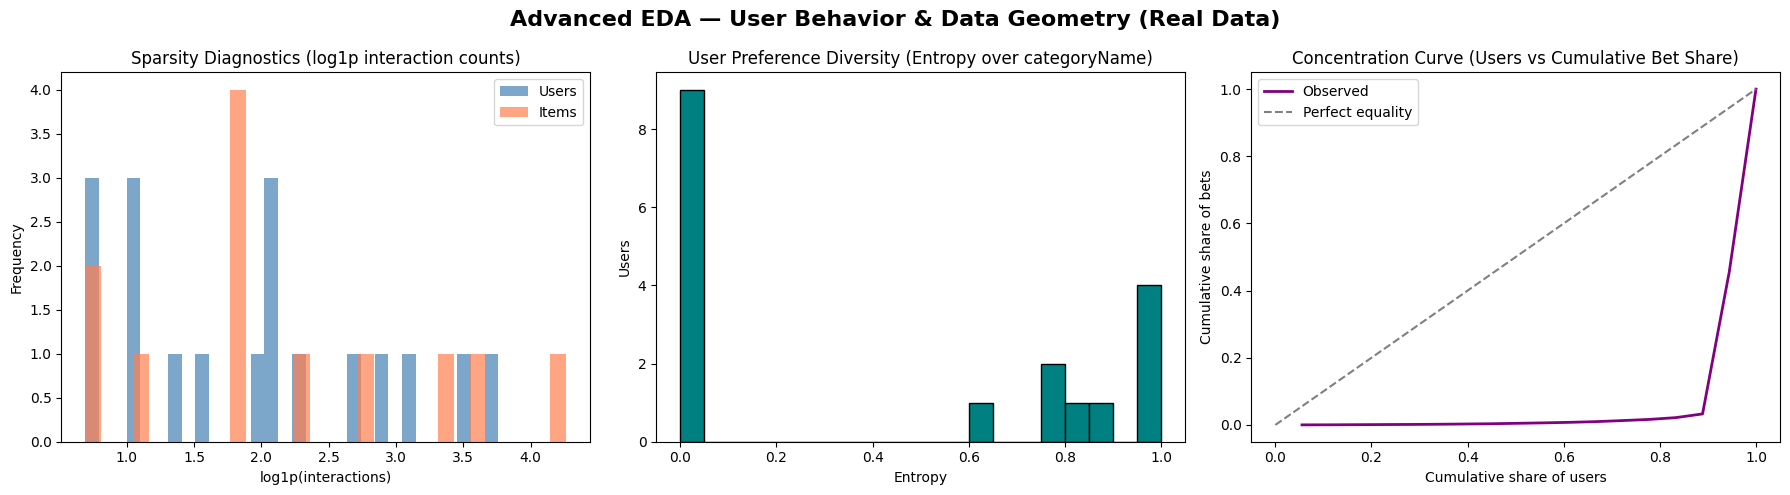

  Active users: 18
  Active items: 12
  Unique (user, game) pairs: 36
  Interaction density (active space): 16.67%
  Median user entropy: 0.307


In [16]:
# Advanced EDA — adapted for real data (no cohort heatmap since no joinedAt)

# 1) Sparsity diagnostics
user_interactions = transactions_df.groupby('userId').size()
item_interactions = transactions_df.groupby('gameName').size()

# 2) Preference diversity (entropy over categoryName)
cat_col = 'categoryName' if 'categoryName' in transactions_df.columns else 'gameName'
gt_counts = transactions_df.groupby(['userId', cat_col]).size().rename('n').reset_index()
user_totals = gt_counts.groupby('userId')['n'].sum().rename('total').reset_index()
entropy_df = gt_counts.merge(user_totals, on='userId', how='left')
entropy_df['p'] = entropy_df['n'] / entropy_df['total']
user_entropy = entropy_df.groupby('userId')['p'].apply(lambda x: -(x * np.log2(x + 1e-12)).sum())

# 3) Concentration (Lorenz-style cumulative share of bets)
user_bets = transactions_df.groupby('userId')['betAmount'].sum().sort_values().values
cum_users = np.arange(1, len(user_bets) + 1) / len(user_bets)
cum_bets  = np.cumsum(user_bets) / np.sum(user_bets)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Advanced EDA — User Behavior & Data Geometry (Real Data)', fontsize=16, fontweight='bold')

# Plot 1: Sparsity diagnostics
axes[0].hist(np.log1p(user_interactions), bins=30, alpha=0.7, label='Users', color='steelblue')
axes[0].hist(np.log1p(item_interactions), bins=30, alpha=0.7, label='Items', color='coral')
axes[0].set_title('Sparsity Diagnostics (log1p interaction counts)')
axes[0].set_xlabel('log1p(interactions)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Plot 2: User preference diversity (entropy)
axes[1].hist(user_entropy, bins=20, color='teal', edgecolor='black')
axes[1].set_title(f'User Preference Diversity (Entropy over {cat_col})')
axes[1].set_xlabel('Entropy')
axes[1].set_ylabel('Users')

# Plot 3: Concentration curve
axes[2].plot(cum_users, cum_bets, label='Observed', color='purple', linewidth=2)
axes[2].plot([0, 1], [0, 1], '--', color='gray', label='Perfect equality')
axes[2].set_title('Concentration Curve (Users vs Cumulative Bet Share)')
axes[2].set_xlabel('Cumulative share of users')
axes[2].set_ylabel('Cumulative share of bets')
axes[2].legend()

plt.tight_layout()
plt.show()

n_pairs = transactions_df.groupby(['userId', 'gameName']).ngroups
interaction_density = n_pairs / (transactions_df['userId'].nunique() * transactions_df['gameName'].nunique())
print(f'  Active users: {transactions_df["userId"].nunique():,}')
print(f'  Active items: {transactions_df["gameName"].nunique():,}')
print(f'  Unique (user, game) pairs: {n_pairs:,}')
print(f'  Interaction density (active space): {interaction_density * 100:.2f}%')
print(f'  Median user entropy: {user_entropy.median():.3f}')

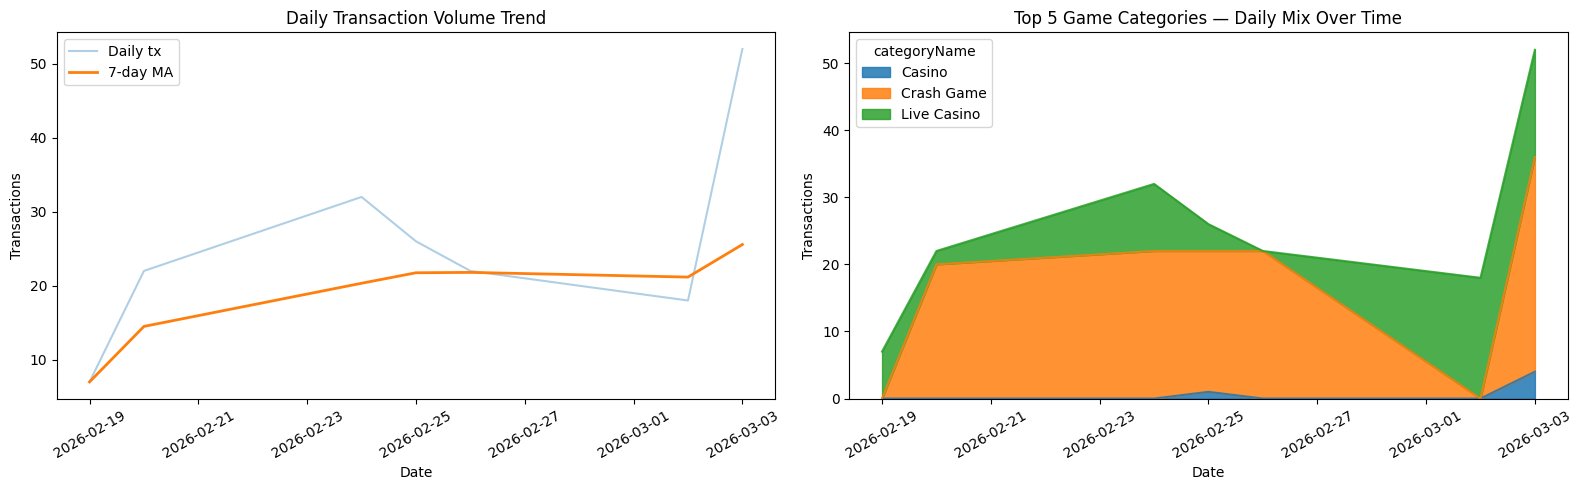

In [17]:
# Daily activity trend + 7-day moving average + Top game types stacked area

plot_df = transactions_df.copy()
plot_df['date'] = plot_df['timestamp'].dt.date

daily_tx = plot_df.groupby('date').size().rename('tx_count').reset_index()
daily_tx['tx_ma7'] = daily_tx['tx_count'].rolling(7, min_periods=1).mean()

# Top game types (use categoryName if available)
top_col = 'categoryName' if 'categoryName' in plot_df.columns else 'gameName'
top_game_types = plot_df[top_col].value_counts().head(5).index
stacked = (
    plot_df[plot_df[top_col].isin(top_game_types)]
    .groupby(['date', top_col])
    .size()
    .unstack(fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(daily_tx['date'], daily_tx['tx_count'], alpha=0.35, label='Daily tx')
axes[0].plot(daily_tx['date'], daily_tx['tx_ma7'], linewidth=2, label='7-day MA')
axes[0].set_title('Daily Transaction Volume Trend')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Transactions')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

stacked.plot(kind='area', ax=axes[1], alpha=0.85)
axes[1].set_title(f'Top 5 Game Categories — Daily Mix Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Transactions')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

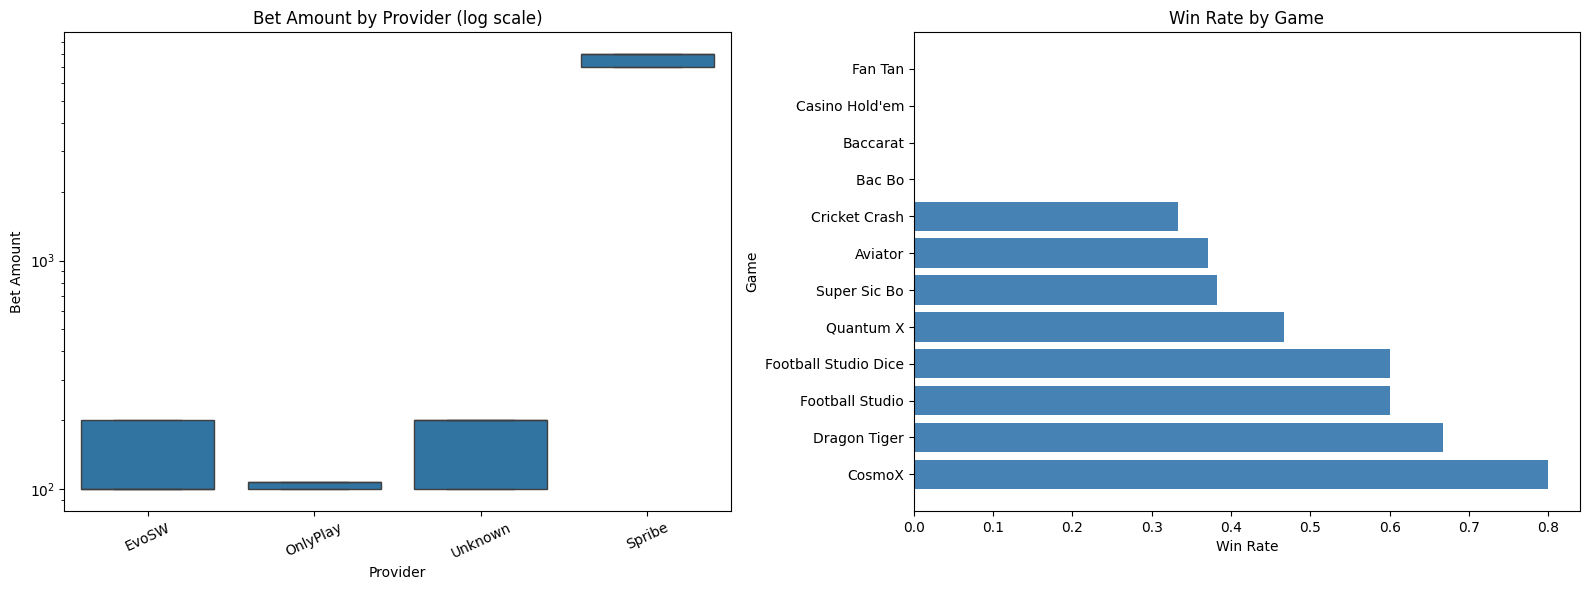

In [18]:
# Bet amount by provider (replaces archetype-based boxplot from recsys.ipynb)
# Since real data has no archetype, we segment by providerName instead

provider_col = 'providerName' if 'providerName' in transactions_df.columns else 'gameName'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=transactions_df,
    x=provider_col,
    y='betAmount',
    showfliers=False,
    ax=axes[0]
)
axes[0].set_yscale('log')
axes[0].set_title('Bet Amount by Provider (log scale)')
axes[0].set_xlabel('Provider')
axes[0].set_ylabel('Bet Amount')
axes[0].tick_params(axis='x', rotation=25)

# Win rate by game
win_rate_by_game = transactions_df.groupby('gameName')['win'].mean().sort_values(ascending=False)
axes[1].barh(win_rate_by_game.index, win_rate_by_game.values, color='steelblue')
axes[1].set_title('Win Rate by Game')
axes[1].set_xlabel('Win Rate')
axes[1].set_ylabel('Game')

plt.tight_layout()
plt.show()

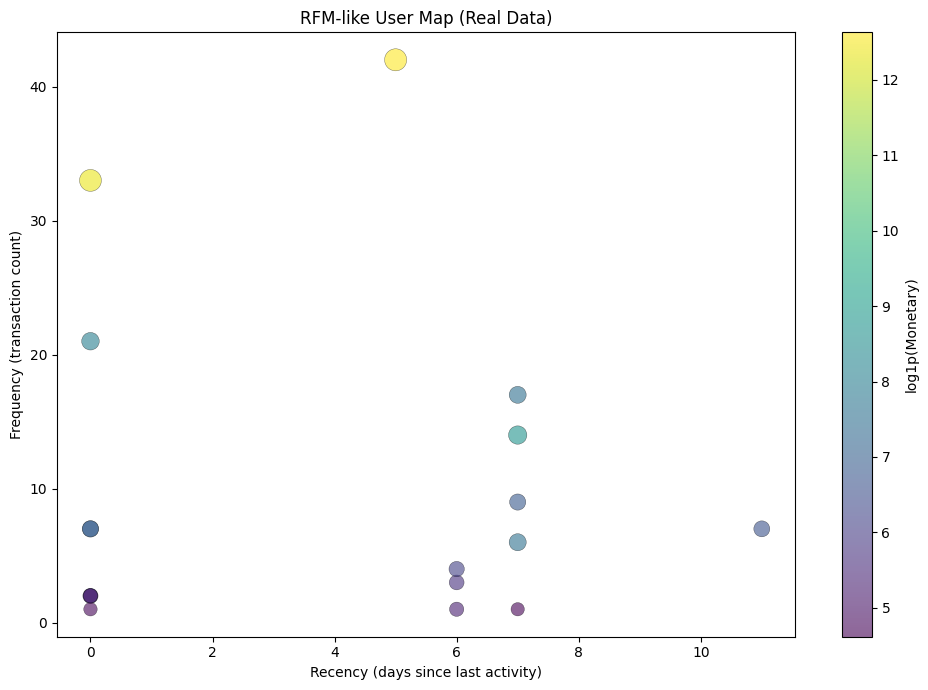


RFM Summary:
       recency_days  frequency   monetary
count         18.00      18.00      18.00
mean           3.83       9.94   31235.72
std            3.71      11.64   88344.62
min            0.00       1.00     100.00
25%            0.00       2.00     225.00
50%            5.50       6.50     735.00
75%            7.00      12.75    1883.25
max           11.00      42.00  306000.00


In [19]:
# User-level RFM-style map (Recency vs Frequency, bubble=Monetary)
# No archetype in real data — uses plain scatter without hue

rfm = transactions_df.groupby('userId').agg(
    frequency=('betAmount', 'count'),
    monetary=('betAmount', 'sum'),
    last_ts=('timestamp', 'max')
).reset_index()
rfm['recency_days'] = (transactions_df['timestamp'].max() - rfm['last_ts']).dt.days

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    rfm['recency_days'],
    rfm['frequency'],
    s=np.log1p(rfm['monetary']) * 20,
    alpha=0.6,
    c=np.log1p(rfm['monetary']),
    cmap='viridis',
    edgecolors='black',
    linewidths=0.3,
)
plt.colorbar(scatter, label='log1p(Monetary)')
plt.title('RFM-like User Map (Real Data)')
plt.xlabel('Recency (days since last activity)')
plt.ylabel('Frequency (transaction count)')
plt.tight_layout()
plt.show()

print(f'\nRFM Summary:')
print(rfm[['recency_days', 'frequency', 'monetary']].describe().round(2))

---
## CELL 3 — Feature Engineering
> Builds the 3 inputs LightFM needs:
> 1. Interaction matrix (user × game with implicit score)
> 2. User feature matrix
> 3. Item feature matrix
>
> **Adapted for real data:** No sessionDuration available, so implicit score uses frequency + bet + recency + win_rate

In [20]:
# Computing implicit score — adapted for real data (no sessionDuration)
# Uses: frequency, bet amount, recency, win rate

TODAY = pd.Timestamp.now()
transactions_df['days_ago'] = (TODAY - transactions_df['timestamp']).dt.days

interaction_agg = transactions_df.groupby(['userId', 'gameName']).agg(
    play_count            = ('betAmount', 'count'),
    total_bet             = ('betAmount', 'sum'),
    avg_bet               = ('betAmount', 'mean'),
    win_rate              = ('win', 'mean'),
    last_played_days_ago  = ('days_ago', 'min'),
).reset_index()


def compute_implicit_score(row):
    # Recency weight
    d = row['last_played_days_ago']
    recency_w = 1.0 if d <= 7 else (0.7 if d <= 30 else (0.4 if d <= 90 else 0.2))

    freq_score    = min(row['play_count'] / 20.0, 1.0)
    bet_score     = min(row['total_bet'] / 500000.0, 1.0)
    win_score     = row['win_rate']  # 0 to 1 naturally

    # Weights redistributed: sessionDuration weight (0.20) split across others
    # Original: 0.35*freq + 0.25*bet + 0.20*session + 0.20*recency
    # Adapted:  0.40*freq + 0.25*bet + 0.15*win + 0.20*recency
    return round(0.40 * freq_score + 0.25 * bet_score + 0.15 * win_score + 0.20 * recency_w, 4)


interaction_agg['implicit_score'] = interaction_agg.apply(compute_implicit_score, axis=1)

print(f"Interaction pairs: {len(interaction_agg):,}")
print(interaction_agg['implicit_score'].describe().round(3))

Interaction pairs: 36
count    36.000
mean      0.322
std       0.136
min       0.160
25%       0.235
50%       0.310
75%       0.347
max       0.832
Name: implicit_score, dtype: float64


In [21]:
# User features — adapted for real data
# No archetype, no sessionDuration, no country/device (not in players collection)

user_features_agg = transactions_df.groupby('userId').agg(
    total_sessions        = ('betAmount', 'count'),
    avg_bet               = ('betAmount', 'mean'),
    total_bet             = ('betAmount', 'sum'),
    unique_games_played   = ('gameName', 'nunique'),
    preferred_hour        = ('hourOfDay', lambda x: x.mode()[0] if len(x.mode()) > 0 else 0),
    preferred_day         = ('dayOfWeek', lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'),
    last_active_days_ago  = ('days_ago', 'min'),
    sessions_last_7d      = ('days_ago', lambda x: (x <= 7).sum()),
    sessions_last_30d     = ('days_ago', lambda x: (x <= 30).sum()),
    avg_win_rate          = ('win', 'mean'),
).reset_index()

# Preferred game category per user
cat_col = 'categoryName' if 'categoryName' in transactions_df.columns else 'gameName'
preferred_category = (
    transactions_df.groupby(['userId', cat_col])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .groupby('userId')
    .first()
    .reset_index()[['userId', cat_col]]
    .rename(columns={cat_col: 'preferred_category'})
)

# Preferred provider per user
if 'providerName' in transactions_df.columns:
    preferred_provider = (
        transactions_df.groupby(['userId', 'providerName'])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
        .groupby('userId')
        .first()
        .reset_index()[['userId', 'providerName']]
        .rename(columns={'providerName': 'preferred_provider'})
    )
    user_features_df = user_features_agg.merge(preferred_category, on='userId', how='left')
    user_features_df = user_features_df.merge(preferred_provider, on='userId', how='left')
else:
    user_features_df = user_features_agg.merge(preferred_category, on='userId', how='left')

print(f"User features shape: {user_features_df.shape}")
user_features_df.head(3)

User features shape: (18, 13)


,userId,total_sessions,avg_bet,total_bet,unique_games_played,preferred_hour,preferred_day,last_active_days_ago,sessions_last_7d,sessions_last_30d,avg_win_rate,preferred_category,preferred_provider
0,3265459874,9,100.000000,900,3,10,Tuesday,8,0,9,0.444444,Crash Game,OnlyPlay
1,3265967463,3,100.000000,300,1,13,Tuesday,8,0,3,0.333333,Live Casino,EvoSW
2,4588888888,33,7206.060606,237800,2,12,Tuesday,1,33,33,0.212121,Crash Game,Spribe


In [22]:
# Item features — adapted for real data

game_popularity = transactions_df.groupby('gameName').agg(
    total_plays       = ('betAmount', 'count'),
    unique_players    = ('userId', 'nunique'),
    avg_bet_on_game   = ('betAmount', 'mean'),
    avg_win_rate_game = ('win', 'mean'),
).reset_index()

# Merge with games_df to get gameType, minBet, maxBet
item_features_df = game_popularity.merge(
    games_df[['gameName', 'gameType', 'minBet', 'maxBet']],
    on='gameName',
    how='left'
).fillna({'gameType': 'Unknown', 'minBet': 0, 'maxBet': 0})

# Add provider info from transactions
provider_per_game = (
    transactions_df.groupby('gameName')['providerName']
    .agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown')
    .reset_index()
    .rename(columns={'providerName': 'vendor'})
) if 'providerName' in transactions_df.columns else None

if provider_per_game is not None:
    item_features_df = item_features_df.merge(provider_per_game, on='gameName', how='left')
    item_features_df['vendor'] = item_features_df['vendor'].fillna('Unknown')

# Log-normalize popularity (heavy hitters won't dominate)
item_features_df['popularity_score'] = np.log1p(item_features_df['total_plays'])

# Bet range
item_features_df['betRange'] = item_features_df['maxBet'] - item_features_df['minBet']

print(f'Item features shape: {item_features_df.shape}')
item_features_df.head()

Item features shape: (13, 11)


,gameName,total_plays,unique_players,avg_bet_on_game,avg_win_rate_game,gameType,minBet,maxBet,vendor,popularity_score,betRange
0,Aviator,70,2,7571.428571,0.371429,Spribe,100.0,100000.0,Spribe,4.262680,99900.0
1,Aviator,70,2,7571.428571,0.371429,Crash,100.0,100000.0,Spribe,4.262680,99900.0
2,Bac Bo,1,1,100.000000,0.000000,Live Casino,100.0,100000.0,EvoSW,0.693147,99900.0
3,Baccarat,5,4,160.000000,0.000000,Unknown,0.0,0.0,Unknown,1.791759,0.0
4,Casino Hold'em,1,1,100.000000,0.000000,Live Casino,100.0,100000.0,EvoSW,0.693147,99900.0


In [23]:
# Additional feature engineering — bet-to-limit ratio, game loyalty, recency bucket

# 1) Bet-to-limit ratio (user aggressiveness)
bet_ratio = (
    interaction_agg
    .merge(item_features_df[['gameName', 'maxBet']], on='gameName', how='left')
    .assign(bet_to_limit_ratio=lambda x: x['avg_bet'] / np.maximum(x['maxBet'], 1))
    .groupby('userId', as_index=False)['bet_to_limit_ratio']
    .mean()
)
user_features_df = user_features_df.merge(bet_ratio, on='userId', how='left')

# 2) Game loyalty score (user-level feature)
game_loyalty = interaction_agg.groupby('userId', as_index=False).agg(
    avg_plays_per_game = ('play_count', 'mean'),
    return_rate        = ('play_count', lambda x: (x > 1).mean())
)
user_features_df = user_features_df.merge(game_loyalty, on='userId', how='left')

# 3) Recency bucket for each user-game pair
interaction_agg['recency_bucket'] = pd.cut(
    interaction_agg['last_played_days_ago'],
    bins=[-1, 7, 30, 90, np.inf],
    labels=['recent', 'moderate', 'old', 'stale']
)

# Fill missing values from merges
for col in ['bet_to_limit_ratio', 'avg_plays_per_game', 'return_rate']:
    if col in user_features_df.columns:
        user_features_df[col] = user_features_df[col].fillna(0)

print(f'Updated user features shape: {user_features_df.shape}')
print(f'Item features shape: {item_features_df.shape}')
print('\nBet-to-limit ratio stats:')
print(user_features_df['bet_to_limit_ratio'].describe().round(3))
print('\nGame loyalty stats:')
print(user_features_df[['avg_plays_per_game', 'return_rate']].describe().round(3))
print('\nRecency bucket counts:')
print(interaction_agg['recency_bucket'].value_counts(dropna=False))

Updated user features shape: (18, 16)
Item features shape: (13, 11)

Bet-to-limit ratio stats:
count     18.000
mean      26.408
std       51.606
min        0.001
25%        0.001
50%        0.068
75%       38.484
max      200.000
Name: bet_to_limit_ratio, dtype: float64

Game loyalty stats:
       avg_plays_per_game  return_rate
count              18.000       18.000
mean                5.770        0.593
std                 9.747        0.432
min                 1.000        0.000
25%                 1.250        0.083
50%                 3.000        0.667
75%                 4.550        1.000
max                42.000        1.000

Recency bucket counts:
recency_bucket
recent      21
moderate    15
old          0
stale        0
Name: count, dtype: int64


In [24]:
# Engineered feature bucketing — needed for LightFM categorical tokens

# User-level buckets
user_features_df['engagement_bucket'] = pd.qcut(
    user_features_df['total_sessions'].rank(method='first'),
    q=4,
    labels=['low', 'mid_low', 'mid_high', 'high']
).astype(str)

user_features_df['user_recency_bucket'] = pd.cut(
    user_features_df['last_active_days_ago'],
    bins=[-1, 7, 30, 90, np.inf],
    labels=['recent', 'moderate', 'old', 'stale']
).astype(str)

user_features_df['diversity_ratio'] = (
    user_features_df['unique_games_played'] / np.maximum(user_features_df['total_sessions'], 1)
).clip(0, 1)
user_features_df['diversity_bucket'] = pd.cut(
    user_features_df['diversity_ratio'],
    bins=[-0.01, 0.2, 0.5, 0.8, 1.0],
    labels=['very_low', 'low', 'medium', 'high']
).astype(str)

user_features_df['aggr_bet_bucket'] = pd.qcut(
    user_features_df['bet_to_limit_ratio'].rank(method='first'),
    q=4,
    labels=['low', 'mid_low', 'mid_high', 'high']
).astype(str)

user_features_df['loyalty_bucket'] = pd.cut(
    user_features_df['return_rate'],
    bins=[-0.01, 0.25, 0.5, 0.75, 1.0],
    labels=['very_low', 'low', 'medium', 'high']
).astype(str)

# Item-level buckets
item_features_df['bet_tier'] = pd.qcut(
    item_features_df['minBet'].rank(method='first'),
    q=min(4, len(item_features_df)),
    labels=['tier1', 'tier2', 'tier3', 'tier4'][:min(4, len(item_features_df))]
).astype(str)

item_features_df['popularity_bucket'] = pd.qcut(
    item_features_df['popularity_score'].rank(method='first'),
    q=min(4, len(item_features_df)),
    labels=['cold', 'warm', 'hot', 'blockbuster'][:min(4, len(item_features_df))]
).astype(str)

print("User feature buckets added:")
print(user_features_df[['engagement_bucket', 'user_recency_bucket', 'diversity_bucket',
                          'aggr_bet_bucket', 'loyalty_bucket']].describe())
print("\nItem feature buckets added:")
print(item_features_df[['bet_tier', 'popularity_bucket']].describe())

User feature buckets added:
       engagement_bucket user_recency_bucket diversity_bucket aggr_bet_bucket  \
count                 18                  18               18              18   
unique                 4                   2                3               4   
top                 high              recent              low             low   
freq                   5                  11                9               5   

       loyalty_bucket  
count              18  
unique              4  
top              high  
freq                8  

Item feature buckets added:
       bet_tier popularity_bucket
count        13                13
unique        4                 4
top       tier1              cold
freq          4                 4


In [25]:
# === FINAL FEATURE ENGINEERING READINESS CHECK ===

print("=" * 60)
print("  FEATURE ENGINEERING — READINESS SUMMARY (REAL DATA)")
print("=" * 60)

print(f"\n--- Interaction Matrix ---")
print(f"  Total (user, game) pairs:    {len(interaction_agg):,}")
print(f"  Unique users:                {interaction_agg['userId'].nunique():,}")
print(f"  Unique games:                {interaction_agg['gameName'].nunique():,}")
print(f"  Implicit score range:        [{interaction_agg['implicit_score'].min():.4f}, {interaction_agg['implicit_score'].max():.4f}]")

print(f"\n--- User Features (shape: {user_features_df.shape}) ---")
print(f"  Numeric:  total_sessions, avg_bet, total_bet, unique_games_played,")
print(f"            sessions_last_7d, sessions_last_30d, avg_win_rate,")
print(f"            bet_to_limit_ratio, avg_plays_per_game, return_rate, diversity_ratio")
print(f"  Categorical: preferred_category, preferred_provider (if available),")
print(f"               engagement_bucket, user_recency_bucket, diversity_bucket,")
print(f"               aggr_bet_bucket, loyalty_bucket")

print(f"\n--- Item Features (shape: {item_features_df.shape}) ---")
print(f"  Numeric:  total_plays, unique_players, avg_bet_on_game, avg_win_rate_game,")
print(f"            popularity_score, betRange, minBet, maxBet")
print(f"  Categorical: gameType, vendor (if available), bet_tier, popularity_bucket")

print(f"\n--- Data Quality ---")
print(f"  User features nulls:\n{user_features_df.isnull().sum()[user_features_df.isnull().sum() > 0]}")
print(f"  Item features nulls:\n{item_features_df.isnull().sum()[item_features_df.isnull().sum() > 0]}")

print(f"\n--- Known Limitations ---")
print(f"  Volume: Only {len(transactions_df)} transactions — too sparse for reliable model training")
print(f"  No sessionDuration: Dropped (unreliable), implicit score adapted with win_rate")
print(f"  No user demographics: No country/device/archetype in real players data")
print(f"  Ready for model training once more data accumulates")
print("=" * 60)

  FEATURE ENGINEERING — READINESS SUMMARY (REAL DATA)

--- Interaction Matrix ---
  Total (user, game) pairs:    36
  Unique users:                18
  Unique games:                12
  Implicit score range:        [0.1600, 0.8316]

--- User Features (shape: (18, 22)) ---
  Numeric:  total_sessions, avg_bet, total_bet, unique_games_played,
            sessions_last_7d, sessions_last_30d, avg_win_rate,
            bet_to_limit_ratio, avg_plays_per_game, return_rate, diversity_ratio
  Categorical: preferred_category, preferred_provider (if available),
               engagement_bucket, user_recency_bucket, diversity_bucket,
               aggr_bet_bucket, loyalty_bucket

--- Item Features (shape: (13, 13)) ---
  Numeric:  total_plays, unique_players, avg_bet_on_game, avg_win_rate_game,
            popularity_score, betRange, minBet, maxBet
  Categorical: gameType, vendor (if available), bet_tier, popularity_bucket

--- Data Quality ---
  User features nulls:
Series([], dtype: int64)
  Ite